# Hamming-Controlled Barrier vs Overlap Length

Investigates whether the **max z-score distance barrier** along a GA-optimised mutation path increases with overlap length, **controlling for Hamming distance**.

## Strategy: Pool-then-Search with Auto-Selected Hamming Target
1. **Phase 1**: For each overlap, generate a **pool** of converged sequences (|z1| < threshold AND |z2| < threshold)
2. **Auto-select Hamming target**: Sample pairwise Hamming distributions from every pool, sweep candidate targets, and pick the one that maximises the minimum number of available pairs across **all** overlaps
3. **Phase 2**: For each overlap, select N non-overlapping pairs near the auto-selected target Hamming distance, then run GA to find optimal mutation orderings
4. Record the max barrier along each path

This avoids failures from a hardcoded Hamming target that doesn't fit all overlap lengths.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
from thesis_plots import *
apply_style()

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import pickle
import json
import os
import warnings
from multiprocessing import Pool
from tqdm.auto import tqdm


import overlappingGenes as og
from ga_worker import (
    generate_single_sequence,
    run_ga_on_pair,
    GeneticPathFinder,
    find_pair_with_target_hamming,
    hamming_distance,
    get_path_energies
)

warnings.filterwarnings('ignore')

np.random.seed(42)

In [3]:
# ===================== CONFIGURATION =====================

# Protein pair
PROTEIN_1 = 'PF00153'
PROTEIN_2 = 'PF00271'

# Tag used in all output filenames
PAIR_TAG = f"{PROTEIN_1}_{PROTEIN_2}"
print(f'PAIR_TAG: {PAIR_TAG}')

# Overlap sweep
OVERLAP_START = 27
OVERLAP_STOP = 216
OVERLAP_STEP = 7

# Convergence filter: both |z1| and |z2| must be below this
Z_SCORE_THRESHOLD = 1.0

# Phase 1: sequence pool generation
MC_RUNS_DEFAULT = 1_000
MC_ITERS_DEFAULT = 200_000

# Per-overlap overrides
MC_RUNS_OVERRIDE = {}
MC_ITERS_OVERRIDE = {}

# Hamming distance control — auto-selected after Phase 1
HAMMING_TOLERANCE = 20            # window half-width around the chosen target
N_HAMMING_SAMPLES = 1000          # random pairs to sample per overlap for distribution

# Phase 2: GA trials
N_PAIRS_PER_OVERLAP = 20         # non-overlapping pairs per overlap
GA_POPULATION = 100
GA_GENERATIONS = 200

# Parallelism
N_WORKERS_PHASE1 = 12
N_WORKERS_PHASE2 = 4

# Output files — pair name baked in
CHECKPOINT_FILE = f'hamming_controlled_checkpoint_{PAIR_TAG}.pkl'
RESULTS_CSV = f'hamming_controlled_results_{PAIR_TAG}.csv'

overlaps = list(range(OVERLAP_START, OVERLAP_STOP + 1, OVERLAP_STEP))
print(f"Pair: {PAIR_TAG}")
print(f"Overlaps to test: {overlaps}")
print(f"Total overlaps: {len(overlaps)}")
print(f"\nPer-overlap settings:")
for ov in overlaps:
    runs = MC_RUNS_OVERRIDE.get(ov, MC_RUNS_DEFAULT)
    iters = MC_ITERS_OVERRIDE.get(ov, MC_ITERS_DEFAULT)
    tag = " (override)" if ov in MC_RUNS_OVERRIDE or ov in MC_ITERS_OVERRIDE else ""
    print(f"  ov={ov:3d}: {runs:,} runs x {iters:,} iters{tag}")

PAIR_TAG: PF00153_PF00271
Pair: PF00153_PF00271
Overlaps to test: [27, 34, 41, 48, 55, 62, 69, 76, 83, 90, 97, 104, 111, 118, 125, 132, 139, 146, 153, 160, 167, 174, 181, 188, 195, 202, 209, 216]
Total overlaps: 28

Per-overlap settings:
  ov= 27: 1,000 runs x 200,000 iters
  ov= 34: 1,000 runs x 200,000 iters
  ov= 41: 1,000 runs x 200,000 iters
  ov= 48: 1,000 runs x 200,000 iters
  ov= 55: 1,000 runs x 200,000 iters
  ov= 62: 1,000 runs x 200,000 iters
  ov= 69: 1,000 runs x 200,000 iters
  ov= 76: 1,000 runs x 200,000 iters
  ov= 83: 1,000 runs x 200,000 iters
  ov= 90: 1,000 runs x 200,000 iters
  ov= 97: 1,000 runs x 200,000 iters
  ov=104: 1,000 runs x 200,000 iters
  ov=111: 1,000 runs x 200,000 iters
  ov=118: 1,000 runs x 200,000 iters
  ov=125: 1,000 runs x 200,000 iters
  ov=132: 1,000 runs x 200,000 iters
  ov=139: 1,000 runs x 200,000 iters
  ov=146: 1,000 runs x 200,000 iters
  ov=153: 1,000 runs x 200,000 iters
  ov=160: 1,000 runs x 200,000 iters
  ov=167: 1,000 runs x

In [4]:
# ===================== LOAD DCA PARAMETERS =====================

print(f"Loading DCA parameters for {PROTEIN_1}...")
Jvec_1, hvec_1 = og.extract_params(f'bmDCA/{PROTEIN_1}/{PROTEIN_1}_params.dat')
nat_energies_1 = og.load_natural_energies(f'bmDCA/{PROTEIN_1}/{PROTEIN_1}_naturalenergies.txt')
mean_e1, std_e1 = np.mean(nat_energies_1), np.std(nat_energies_1)

print(f"Loading DCA parameters for {PROTEIN_2}...")
Jvec_2, hvec_2 = og.extract_params(f'bmDCA/{PROTEIN_2}/{PROTEIN_2}_params.dat')
nat_energies_2 = og.load_natural_energies(f'bmDCA/{PROTEIN_2}/{PROTEIN_2}_naturalenergies.txt')
mean_e2, std_e2 = np.mean(nat_energies_2), np.std(nat_energies_2)

prot1_len = len(hvec_1) // 21
prot2_len = len(hvec_2) // 21
print(f"\nProtein 1 length: {prot1_len} AA")
print(f"Protein 2 length: {prot2_len} AA")

# Load optimal temperatures
with open('optimal_temperatures.json', 'r') as f:
    optimal_temps = json.load(f)

mc_temp_1 = optimal_temps[PROTEIN_1]
mc_temp_2 = optimal_temps[PROTEIN_2]
print(f"MC temperature {PROTEIN_1}: {mc_temp_1}")
print(f"MC temperature {PROTEIN_2}: {mc_temp_2}")

print(f"\nNatural energy stats:")
print(f"  {PROTEIN_1}: mean={mean_e1:.2f}, std={std_e1:.2f}")
print(f"  {PROTEIN_2}: mean={mean_e2:.2f}, std={std_e2:.2f}")

Loading DCA parameters for PF00153...
Loading DCA parameters for PF00271...

Protein 1 length: 85 AA
Protein 2 length: 95 AA
MC temperature PF00153: 0.817529
MC temperature PF00271: 0.872126

Natural energy stats:
  PF00153: mean=92.55, std=25.62
  PF00271: mean=149.58, std=27.18


In [5]:
# ===================== NUMBA WARMUP =====================

print("Warming up Numba JIT...")
warmup_overlap = 12
warmup_seq = og.initial_seq_no_stops(prot1_len, prot2_len, warmup_overlap, quiet=True)
_ = og.overlapped_sequence_generator_int(
    (Jvec_1, hvec_1), (Jvec_2, hvec_2), warmup_seq,
    T1=mc_temp_1, T2=mc_temp_2,
    numberofiterations=100, quiet=True, whentosave=100.0,
    nat_mean1=mean_e1, nat_mean2=mean_e2,
    nat_std1=std_e1, nat_std2=std_e2,
    use_z_score=True
)
print("Warmup complete.")

Warming up Numba JIT...
Warmup complete.


In [5]:
# ===================== CHECKPOINT RESUME =====================

if os.path.exists(CHECKPOINT_FILE):
    with open(CHECKPOINT_FILE, 'rb') as f:
        checkpoint = pickle.load(f)
    all_results = checkpoint['all_results']
    completed_overlaps = checkpoint['completed_overlaps']
    pool_cache = checkpoint['pool_cache']
    print(f"Resumed from checkpoint: {len(completed_overlaps)} overlaps completed")
    print(f"  Completed: {sorted(completed_overlaps)}")
else:
    all_results = []
    completed_overlaps = set()
    pool_cache = {}  # overlap -> list of (sequence, z1, z2)
    print("Starting fresh (no checkpoint found).")

Starting fresh (no checkpoint found).


In [6]:
# ===================== HELPER FUNCTIONS =====================

def compute_reading_frame(overlap):
    """Compute the reading frame for a given overlap length.
    Consistent with Large Scale notebooks:
      overlap % 3 == 0  ->  Frame 0  (in-frame)
      overlap % 3 == 1  ->  Frame +1 (shifted by 1nt)
      overlap % 3 == 2  ->  Frame +2 (shifted by 2nt)"""
    return overlap % 3


def filter_converged(sequences_with_energies, threshold=Z_SCORE_THRESHOLD):
    """Filter sequences to those where both |z1| < threshold AND |z2| < threshold.
    Input: list of (sequence_str, best_energies_array)
    Returns: list of (sequence_str, z1, z2)"""
    converged = []
    for seq, energies in sequences_with_energies:
        z1 = (energies[0] - mean_e1) / std_e1
        z2 = (energies[1] - mean_e2) / std_e2
        if abs(z1) < threshold and abs(z2) < threshold:
            converged.append((seq, z1, z2))
    return converged


def hamming_per_gene(seq1, seq2, l1, l2):
    """Compute Hamming distance per gene and return (h1, h2, h1+h2).
    Gene 1 occupies seq[:l1], gene 2 occupies seq[-l2:].
    Overlap-region mutations are counted in both genes."""
    h1 = sum(c1 != c2 for c1, c2 in zip(seq1[:l1], seq2[:l1]))
    h2 = sum(c1 != c2 for c1, c2 in zip(seq1[-l2:], seq2[-l2:]))
    return h1, h2, h1 + h2


def select_n_pairs(sequences, n, target_h, tolerance, l1, l2):
    """Greedy non-overlapping pair selection using vectorised per-gene Hamming distances.
    Converts sequences to a 2D uint8 array and computes per-gene Hamming
    distances (gene1 = seq[:l1], gene2 = seq[-l2:]), then greedily picks
    non-overlapping pairs closest to target_h.
    Returns: list of (i, j, hamming_dist) tuples."""
    n_seqs = len(sequences)
    if n_seqs < 2:
        return []

    # Convert all sequences to a 2D numpy array for vectorised comparison
    seq_len = len(sequences[0][0])
    arr = np.empty((n_seqs, seq_len), dtype='U1')
    for i, (seq, _, _) in enumerate(sequences):
        arr[i] = list(seq)

    # Compute upper triangle of pairwise per-gene Hamming distances
    candidates = []
    for i in range(n_seqs):
        # Per-gene diffs: gene1 = [:l1], gene2 = [-l2:]
        diffs_g1 = (arr[i, :l1] != arr[i+1:, :l1]).sum(axis=1)
        diffs_g2 = (arr[i, -l2:] != arr[i+1:, -l2:]).sum(axis=1)
        diffs = diffs_g1 + diffs_g2
        for k, h in enumerate(diffs):
            j = i + 1 + k
            diff = abs(int(h) - target_h)
            if diff <= tolerance:
                candidates.append((diff, i, j, int(h)))

    # Sort by closeness to target
    candidates.sort(key=lambda x: x[0])

    # Greedy non-overlapping selection
    used = set()
    selected = []
    for diff, i, j, h in candidates:
        if i not in used and j not in used:
            selected.append((i, j, h))
            used.add(i)
            used.add(j)
            if len(selected) >= n:
                break

    return selected


# Print reading frame diagnostic
print("Reading frame per overlap:")
for ov in overlaps:
    rf = compute_reading_frame(ov)
    print(f"  overlap={ov:3d} -> Frame +{rf}")

unique_frames = set(compute_reading_frame(ov) for ov in overlaps)
if len(unique_frames) == 1:
    frame_val = unique_frames.pop()
    print(f"\nWARNING: All overlaps land in Frame +{frame_val}. "
          f"To sample multiple frames, use an OVERLAP_STEP that is not "
          f"divisible by 3.")

Reading frame per overlap:
  overlap= 27 -> Frame +0
  overlap= 34 -> Frame +1
  overlap= 41 -> Frame +2
  overlap= 48 -> Frame +0
  overlap= 55 -> Frame +1
  overlap= 62 -> Frame +2
  overlap= 69 -> Frame +0
  overlap= 76 -> Frame +1
  overlap= 83 -> Frame +2
  overlap= 90 -> Frame +0
  overlap= 97 -> Frame +1
  overlap=104 -> Frame +2
  overlap=111 -> Frame +0
  overlap=118 -> Frame +1
  overlap=125 -> Frame +2
  overlap=132 -> Frame +0
  overlap=139 -> Frame +1
  overlap=146 -> Frame +2
  overlap=153 -> Frame +0
  overlap=160 -> Frame +1
  overlap=167 -> Frame +2
  overlap=174 -> Frame +0
  overlap=181 -> Frame +1
  overlap=188 -> Frame +2
  overlap=195 -> Frame +0
  overlap=202 -> Frame +1
  overlap=209 -> Frame +2
  overlap=216 -> Frame +0


In [7]:
# ===================== PHASE 1: GENERATE ALL POOLS =====================

seed_counter = 1000

for overlap in overlaps:
    if overlap in pool_cache and len(pool_cache[overlap]) >= 2:
        print(f"Overlap {overlap}: cached pool ({len(pool_cache[overlap])} converged), skipping.")
        continue

    reading_frame = compute_reading_frame(overlap)
    mc_runs = MC_RUNS_OVERRIDE.get(overlap, MC_RUNS_DEFAULT)
    mc_iters = MC_ITERS_OVERRIDE.get(overlap, MC_ITERS_DEFAULT)

    print(f"\n{'='*60}")
    print(f"Overlap {overlap} (Frame +{reading_frame}) — {mc_runs:,} runs x {mc_iters:,} iters")
    print(f"{'='*60}")

    args_list = []
    for i in range(mc_runs):
        seed_counter += 1
        args_list.append((
            overlap, 0, i, seed_counter,
            Jvec_1, hvec_1, Jvec_2, hvec_2,
            prot1_len, prot2_len,
            mc_iters, mc_temp_1, mc_temp_2,
            mean_e1, mean_e2, std_e1, std_e2, True
        ))

    with Pool(processes=N_WORKERS_PHASE1) as p:
        results = list(tqdm(
            p.imap_unordered(generate_single_sequence, args_list),
            total=len(args_list),
            desc=f"  Pool gen (ov={overlap})",
            leave=False
        ))

    raw = [(r['sequence'], r['energies']) for r in results if r['success']]
    pool = filter_converged(raw)
    pool_cache[overlap] = pool

    print(f"  {len(raw)} successful, {len(pool)} converged (|z|<{Z_SCORE_THRESHOLD})")

    # Checkpoint after each overlap
    with open(CHECKPOINT_FILE, 'wb') as f:
        pickle.dump({
            'all_results': all_results,
            'completed_overlaps': completed_overlaps,
            'pool_cache': pool_cache
        }, f)

print(f"\nPhase 1 complete. Pool sizes:")
for ov in overlaps:
    n = len(pool_cache.get(ov, []))
    print(f"  ov={ov:3d}: {n} converged sequences")


Overlap 27 (Frame +0) — 1,000 runs x 200,000 iters


  1000 successful, 1000 converged (|z|<1.0)

Overlap 34 (Frame +1) — 1,000 runs x 200,000 iters


  1000 successful, 999 converged (|z|<1.0)

Overlap 41 (Frame +2) — 1,000 runs x 200,000 iters


  1000 successful, 1000 converged (|z|<1.0)

Overlap 48 (Frame +0) — 1,000 runs x 200,000 iters


  1000 successful, 993 converged (|z|<1.0)

Overlap 55 (Frame +1) — 1,000 runs x 200,000 iters


...

  1000 successful, 975 converged (|z|<1.0)

Overlap 195 (Frame +0) — 1,000 runs x 200,000 iters


  1000 successful, 204 converged (|z|<1.0)

Overlap 202 (Frame +1) — 1,000 runs x 200,000 iters


  1000 successful, 0 converged (|z|<1.0)

Overlap 209 (Frame +2) — 1,000 runs x 200,000 iters


  1000 successful, 989 converged (|z|<1.0)

Overlap 216 (Frame +0) — 1,000 runs x 200,000 iters


  1000 successful, 107 converged (|z|<1.0)

Phase 1 complete. Pool sizes:
  ov= 27: 1000 converged sequences
  ov= 34: 999 converged sequences
  ov= 41: 1000 converged sequences
  ov= 48: 993 converged sequences
  ov= 55: 929 converged sequences
  ov= 62: 1000 converged sequences
  ov= 69: 1000 converged sequences
  ov= 76: 981 converged sequences
  ov= 83: 999 converged sequences
  ov= 90: 995 converged sequences
  ov= 97: 622 converged sequences
  ov=104: 1000 converged sequences
  ov=111: 667 converged sequences
  ov=118: 85 converged sequences
  ov=125: 997 converged sequences
  ov=132: 932 converged sequences
  ov=139: 62 converged sequences
  ov=146: 1000 converged sequences
  ov=153: 943 converged sequences
  ov=160: 93 converged sequences
  ov=167: 1000 converged sequences
  ov=174: 623 converged sequences
  ov=181: 0 converged sequences
  ov=188: 975 converged sequences
  ov=195: 204 converged sequences
  ov=202: 0 converged sequences
  ov=209: 989 converged sequences
  ov=216

In [8]:
# ===================== AUTO-SELECT HAMMING TARGET =====================
# Sample pairwise per-gene Hamming distances from each pool, then pick the
# target that maximises the minimum number of available pairs across ALL overlaps.

# Gene lengths in nucleotides (fixed regardless of overlap)
l1 = prot1_len * 3 + 3
l2 = prot2_len * 3 + 3
print(f"Gene lengths: l1={l1} nt, l2={l2} nt")

print("\nSampling pairwise per-gene Hamming distributions per overlap...\n")

hamming_distributions = {}  # overlap -> array of sampled Hamming distances

for ov in overlaps:
    pool = pool_cache.get(ov, [])
    n_pool = len(pool)
    if n_pool < 2:
        print(f"  ov={ov}: pool too small ({n_pool}), skipping")
        continue

    # Random sample of pairs
    n_possible = n_pool * (n_pool - 1) // 2
    n_samples = min(N_HAMMING_SAMPLES, n_possible)

    sampled_h = []
    seen = set()
    attempts = 0
    while len(sampled_h) < n_samples and attempts < n_samples * 10:
        i = np.random.randint(0, n_pool)
        j = np.random.randint(0, n_pool)
        if i >= j:
            attempts += 1
            continue
        if (i, j) in seen:
            attempts += 1
            continue
        seen.add((i, j))
        h = hamming_per_gene(pool[i][0], pool[j][0], l1, l2)[2]
        sampled_h.append(h)
        attempts += 1

    hamming_distributions[ov] = np.array(sampled_h)
    print(f"  ov={ov:3d}: sampled {len(sampled_h)} pairs, "
          f"Hamming range [{min(sampled_h)}-{max(sampled_h)}], "
          f"median={np.median(sampled_h):.0f}")

# --- Sweep candidate targets and score each ---
# Candidate range: union of all sampled values
all_sampled = np.concatenate(list(hamming_distributions.values()))
candidate_min = int(np.percentile(all_sampled, 5))
candidate_max = int(np.percentile(all_sampled, 95))
candidates = np.arange(candidate_min, candidate_max + 1)

print(f"\nSweeping candidate targets from {candidate_min} to {candidate_max}...")

best_target = None
best_min_pairs = -1

# For each candidate, count how many pairs within tolerance each overlap has
scores = []
for h_target in candidates:
    min_pairs_this_target = np.inf
    for ov in overlaps:
        if ov not in hamming_distributions:
            min_pairs_this_target = 0
            break
        dist = hamming_distributions[ov]
        n_in_window = np.sum(np.abs(dist - h_target) <= HAMMING_TOLERANCE)
        # Scale by total possible pairs to estimate how many non-overlapping
        # pairs we could actually select (rough proxy)
        min_pairs_this_target = min(min_pairs_this_target, n_in_window)

    scores.append(min_pairs_this_target)
    if min_pairs_this_target > best_min_pairs:
        best_min_pairs = min_pairs_this_target
        best_target = h_target

TARGET_HAMMING = int(best_target)
scores = np.array(scores)

print(f"\n>>> AUTO-SELECTED TARGET_HAMMING = {TARGET_HAMMING} "
      f"(min pairs in window across overlaps: {best_min_pairs})")
print(f"    Tolerance: +/- {HAMMING_TOLERANCE}")

Gene lengths: l1=258 nt, l2=288 nt

Sampling pairwise per-gene Hamming distributions per overlap...

  ov= 27: sampled 1000 pairs, Hamming range [257-371], median=323
  ov= 34: sampled 1000 pairs, Hamming range [259-382], median=320
  ov= 41: sampled 1000 pairs, Hamming range [236-380], median=315
  ov= 48: sampled 1000 pairs, Hamming range [238-373], median=323
  ov= 55: sampled 1000 pairs, Hamming range [233-374], median=299
  ov= 62: sampled 1000 pairs, Hamming range [211-369], median=306
  ov= 69: sampled 1000 pairs, Hamming range [226-356], median=292
  ov= 76: sampled 1000 pairs, Hamming range [234-360], median=302
  ov= 83: sampled 1000 pairs, Hamming range [218-377], median=298
  ov= 90: sampled 1000 pairs, Hamming range [220-363], median=291
  ov= 97: sampled 1000 pairs, Hamming range [210-355], median=296
  ov=104: sampled 1000 pairs, Hamming range [195-355], median=284
  ov=111: sampled 1000 pairs, Hamming range [209-358], median=300
  ov=118: sampled 1000 pairs, Hamming ran

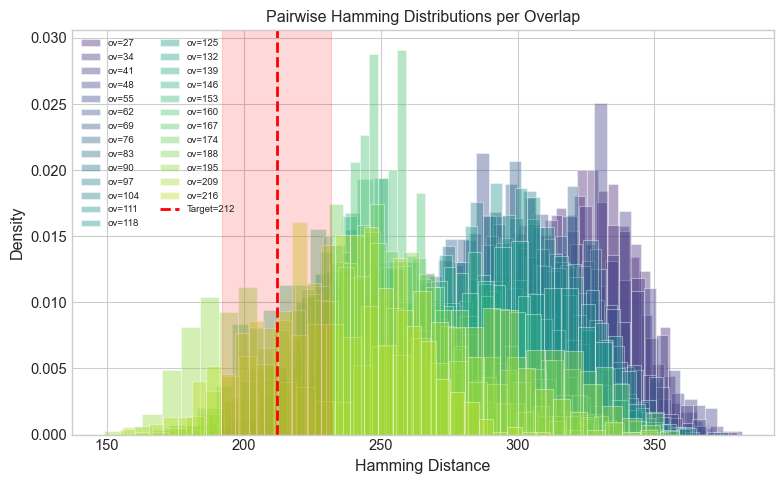

In [9]:
# --- Plot: distributions + chosen target ---
fig,ax = plt.subplots(1, 1, figsize=(8, 5))

# Left: per-overlap Hamming distributions
cmap = plt.cm.viridis(np.linspace(0.1, 0.9, len(hamming_distributions)))
for idx, ov in enumerate(sorted(hamming_distributions.keys())):
    ax.hist(hamming_distributions[ov], bins=30, alpha=0.4, color=cmap[idx],
             label=f'ov={ov}', density=True)
ax.axvline(TARGET_HAMMING, color=VERMILLION, linewidth=2, linestyle='--',
            label=f'Target={TARGET_HAMMING}')
ax.axvspan(TARGET_HAMMING - HAMMING_TOLERANCE, TARGET_HAMMING + HAMMING_TOLERANCE,
            alpha=0.15, color=VERMILLION)
ax.set_xlabel('Hamming Distance')
ax.set_ylabel('Density')
ax.set_title('Pairwise Hamming Distributions per Overlap')
ax.legend(fontsize=7, ncol=2)



plt.tight_layout()
plt.savefig(f'hamming_target_selection_{PAIR_TAG}.png')
plt.show()

In [10]:
# ===================== PHASE 2: PAIR SELECTION + GA =====================

for overlap in overlaps:
    if overlap in completed_overlaps:
        print(f"\nOverlap {overlap}: already completed, skipping.")
        continue

    reading_frame = compute_reading_frame(overlap)
    pool = pool_cache.get(overlap, [])

    print(f"\n{'='*60}")
    print(f"Overlap {overlap} (Frame +{reading_frame})")
    print(f"{'='*60}")

    if len(pool) < 2:
        print(f"  SKIPPING: not enough converged sequences ({len(pool)})")
        completed_overlaps.add(overlap)
        continue

    # --- Pair selection (per-gene Hamming) ---
    selected_pairs = select_n_pairs(pool, N_PAIRS_PER_OVERLAP,
                                     TARGET_HAMMING, HAMMING_TOLERANCE, l1, l2)
    print(f"  Pair selection: found {len(selected_pairs)} non-overlapping pairs "
          f"at per-gene Hamming {TARGET_HAMMING}+/-{HAMMING_TOLERANCE}")

    if len(selected_pairs) == 0:
        all_h = []
        for i in range(len(pool)):
            for j in range(i+1, min(i+50, len(pool))):
                all_h.append(hamming_per_gene(pool[i][0], pool[j][0], l1, l2)[2])
        if all_h:
            print(f"  Available per-gene Hamming range: {min(all_h)}-{max(all_h)}, "
                  f"median={np.median(all_h):.0f}")
        print(f"  SKIPPING: no pairs found within tolerance.")
        completed_overlaps.add(overlap)
        continue

    for i, j, h in selected_pairs:
        print(f"    Pair: seq {i} <-> seq {j}, Hamming={h}")

    # --- Run GA ---
    print(f"  Running GA on {len(selected_pairs)} pairs...")

    ga_args_list = []
    for trial_idx, (i, j, h) in enumerate(selected_pairs):
        seed_counter += 1
        ga_args_list.append((
            pool[i][0], pool[j][0],
            Jvec_1, hvec_1, Jvec_2, hvec_2,
            prot1_len, prot2_len,
            mean_e1, mean_e2, std_e1, std_e2, True,
            GA_POPULATION, GA_GENERATIONS,
            overlap, trial_idx, h, reading_frame, seed_counter
        ))

    with Pool(processes=N_WORKERS_PHASE2) as p:
        ga_results = list(tqdm(
            p.imap_unordered(run_ga_on_pair, ga_args_list),
            total=len(ga_args_list),
            desc=f"  GA (ov={overlap})",
            leave=False
        ))

    n_success = sum(1 for r in ga_results if r['success'])
    barriers = [r['max_barrier'] for r in ga_results if r['success']]
    print(f"  GA done: {n_success}/{len(ga_results)} successful")
    if barriers:
        print(f"  Barriers: mean={np.mean(barriers):.3f}, "
              f"std={np.std(barriers):.3f}, "
              f"range=[{min(barriers):.3f}, {max(barriers):.3f}]")

    all_results.extend(ga_results)
    completed_overlaps.add(overlap)

    # Checkpoint
    with open(CHECKPOINT_FILE, 'wb') as f:
        pickle.dump({
            'all_results': all_results,
            'completed_overlaps': completed_overlaps,
            'pool_cache': pool_cache
        }, f)
    print(f"  Checkpoint saved ({len(completed_overlaps)}/{len(overlaps)} overlaps done).")

print(f"\n{'='*60}")
print(f"All overlaps processed. Total results: {len(all_results)}")


Overlap 27 (Frame +0)
  Pair selection: found 1 non-overlapping pairs at per-gene Hamming 212+/-20
    Pair: seq 142 <-> seq 754, Hamming=230
  Running GA on 1 pairs...


  GA done: 1/1 successful
  Barriers: mean=0.192, std=0.000, range=[0.192, 0.192]
  Checkpoint saved (1/28 overlaps done).

Overlap 34 (Frame +1)
  Pair selection: found 3 non-overlapping pairs at per-gene Hamming 212+/-20
    Pair: seq 418 <-> seq 711, Hamming=229
    Pair: seq 192 <-> seq 621, Hamming=230
    Pair: seq 590 <-> seq 874, Hamming=232
  Running GA on 3 pairs...


  GA done: 3/3 successful
  Barriers: mean=0.393, std=0.098, range=[0.258, 0.487]
  Checkpoint saved (2/28 overlaps done).

Overlap 41 (Frame +2)
  Pair selection: found 20 non-overlapping pairs at per-gene Hamming 212+/-20
    Pair: seq 84 <-> seq 630, Hamming=222
    Pair: seq 959 <-> seq 975, Hamming=223
    Pair: seq 211 <-> seq 739, Hamming=224
    Pair: seq 499 <-> seq 804, Hamming=224
    Pair: seq 750 <-> seq 932, Hamming=224
    Pair: seq 334 <-> seq 515, Hamming=225
    Pair: seq 440 <-> seq 817, Hamming=225
    Pair: seq 492 <-> seq 534, Hamming=225
    Pair: seq 495 <-> seq 962, Hamming=225
    Pair: seq 381 <-> seq 774, Hamming=226
    Pair: seq 489 <-> seq 824, Hamming=226
    Pair: seq 57 <-> seq 338, Hamming=227
    Pair: seq 254 <-> seq 617, Hamming=227
    Pair: seq 333 <-> seq 402, Hamming=227
    Pair: seq 422 <-> seq 989, Hamming=227
    Pair: seq 800 <-> seq 994, Hamming=227
    Pair: seq 879 <-> seq 921, Hamming=227
    Pair: seq 95 <-> seq 612, Hamming=228
    P

  GA done: 20/20 successful
  Barriers: mean=0.249, std=0.092, range=[0.150, 0.478]
  Checkpoint saved (3/28 overlaps done).

Overlap 48 (Frame +0)
  Pair selection: found 20 non-overlapping pairs at per-gene Hamming 212+/-20
    Pair: seq 7 <-> seq 15, Hamming=218
    Pair: seq 390 <-> seq 589, Hamming=218
    Pair: seq 648 <-> seq 653, Hamming=218
    Pair: seq 111 <-> seq 957, Hamming=225
    Pair: seq 770 <-> seq 918, Hamming=226
    Pair: seq 176 <-> seq 321, Hamming=227
    Pair: seq 335 <-> seq 505, Hamming=227
    Pair: seq 741 <-> seq 919, Hamming=227
    Pair: seq 77 <-> seq 581, Hamming=230
    Pair: seq 121 <-> seq 939, Hamming=230
    Pair: seq 235 <-> seq 778, Hamming=230
    Pair: seq 289 <-> seq 413, Hamming=230
    Pair: seq 327 <-> seq 862, Hamming=230
    Pair: seq 3 <-> seq 118, Hamming=231
    Pair: seq 194 <-> seq 256, Hamming=231
    Pair: seq 331 <-> seq 945, Hamming=231
    Pair: seq 378 <-> seq 723, Hamming=231
    Pair: seq 115 <-> seq 665, Hamming=232
    Pa

  GA done: 20/20 successful
  Barriers: mean=0.261, std=0.103, range=[0.150, 0.599]
  Checkpoint saved (4/28 overlaps done).

Overlap 55 (Frame +1)
  Pair selection: found 20 non-overlapping pairs at per-gene Hamming 212+/-20
    Pair: seq 200 <-> seq 760, Hamming=212
    Pair: seq 396 <-> seq 611, Hamming=218
    Pair: seq 68 <-> seq 684, Hamming=221
    Pair: seq 615 <-> seq 754, Hamming=222
    Pair: seq 72 <-> seq 823, Hamming=224
    Pair: seq 70 <-> seq 501, Hamming=225
    Pair: seq 431 <-> seq 798, Hamming=225
    Pair: seq 599 <-> seq 766, Hamming=225
    Pair: seq 683 <-> seq 890, Hamming=225
    Pair: seq 0 <-> seq 866, Hamming=226
    Pair: seq 48 <-> seq 318, Hamming=227
    Pair: seq 180 <-> seq 849, Hamming=227
    Pair: seq 204 <-> seq 383, Hamming=227
    Pair: seq 292 <-> seq 763, Hamming=227
    Pair: seq 445 <-> seq 744, Hamming=227
    Pair: seq 535 <-> seq 842, Hamming=227
    Pair: seq 6 <-> seq 780, Hamming=228
    Pair: seq 63 <-> seq 548, Hamming=228
    Pair:

...

  GA done: 20/20 successful
  Barriers: mean=1.295, std=0.137, range=[0.989, 1.628]
  Checkpoint saved (22/28 overlaps done).

Overlap 181 (Frame +1)
  SKIPPING: not enough converged sequences (0)

Overlap 188 (Frame +2)
  Pair selection: found 20 non-overlapping pairs at per-gene Hamming 212+/-20
    Pair: seq 0 <-> seq 111, Hamming=212
    Pair: seq 1 <-> seq 54, Hamming=212
    Pair: seq 2 <-> seq 285, Hamming=212
    Pair: seq 3 <-> seq 45, Hamming=212
    Pair: seq 4 <-> seq 205, Hamming=212
    Pair: seq 5 <-> seq 121, Hamming=212
    Pair: seq 7 <-> seq 856, Hamming=212
    Pair: seq 8 <-> seq 406, Hamming=212
    Pair: seq 10 <-> seq 207, Hamming=212
    Pair: seq 11 <-> seq 369, Hamming=212
    Pair: seq 12 <-> seq 53, Hamming=212
    Pair: seq 13 <-> seq 238, Hamming=212
    Pair: seq 14 <-> seq 217, Hamming=212
    Pair: seq 15 <-> seq 246, Hamming=212
    Pair: seq 16 <-> seq 87, Hamming=212
    Pair: seq 17 <-> seq 139, Hamming=212
    Pair: seq 18 <-> seq 116, Hamming=212

  GA done: 17/20 successful
  Barriers: mean=0.898, std=0.113, range=[0.637, 1.044]
  Checkpoint saved (24/28 overlaps done).

Overlap 195 (Frame +0)
  Pair selection: found 20 non-overlapping pairs at per-gene Hamming 212+/-20
    Pair: seq 0 <-> seq 47, Hamming=212
    Pair: seq 1 <-> seq 2, Hamming=212
    Pair: seq 4 <-> seq 121, Hamming=212
    Pair: seq 5 <-> seq 120, Hamming=212
    Pair: seq 7 <-> seq 172, Hamming=212
    Pair: seq 8 <-> seq 100, Hamming=212
    Pair: seq 9 <-> seq 123, Hamming=212
    Pair: seq 10 <-> seq 52, Hamming=212
    Pair: seq 11 <-> seq 13, Hamming=212
    Pair: seq 12 <-> seq 197, Hamming=212
    Pair: seq 19 <-> seq 187, Hamming=212
    Pair: seq 20 <-> seq 128, Hamming=212
    Pair: seq 21 <-> seq 131, Hamming=212
    Pair: seq 27 <-> seq 37, Hamming=212
    Pair: seq 29 <-> seq 145, Hamming=212
    Pair: seq 32 <-> seq 38, Hamming=212
    Pair: seq 41 <-> seq 85, Hamming=212
    Pair: seq 43 <-> seq 174, Hamming=212
    Pair: seq 48 <-> seq 61, Ha

  GA done: 20/20 successful
  Barriers: mean=1.134, std=0.297, range=[0.829, 1.787]
  Checkpoint saved (25/28 overlaps done).

Overlap 202 (Frame +1)
  SKIPPING: not enough converged sequences (0)

Overlap 209 (Frame +2)
  Pair selection: found 20 non-overlapping pairs at per-gene Hamming 212+/-20
    Pair: seq 0 <-> seq 121, Hamming=212
    Pair: seq 1 <-> seq 31, Hamming=212
    Pair: seq 2 <-> seq 111, Hamming=212
    Pair: seq 3 <-> seq 241, Hamming=212
    Pair: seq 4 <-> seq 355, Hamming=212
    Pair: seq 5 <-> seq 29, Hamming=212
    Pair: seq 6 <-> seq 26, Hamming=212
    Pair: seq 8 <-> seq 86, Hamming=212
    Pair: seq 9 <-> seq 96, Hamming=212
    Pair: seq 10 <-> seq 181, Hamming=212
    Pair: seq 11 <-> seq 351, Hamming=212
    Pair: seq 12 <-> seq 75, Hamming=212
    Pair: seq 13 <-> seq 16, Hamming=212
    Pair: seq 17 <-> seq 47, Hamming=212
    Pair: seq 18 <-> seq 112, Hamming=212
    Pair: seq 19 <-> seq 758, Hamming=212
    Pair: seq 20 <-> seq 180, Hamming=212
    

  GA done: 15/20 successful
  Barriers: mean=0.835, std=0.092, range=[0.695, 1.007]
  Checkpoint saved (27/28 overlaps done).

Overlap 216 (Frame +0)
  Pair selection: found 20 non-overlapping pairs at per-gene Hamming 212+/-20
    Pair: seq 0 <-> seq 6, Hamming=212
    Pair: seq 2 <-> seq 103, Hamming=212
    Pair: seq 3 <-> seq 29, Hamming=212
    Pair: seq 4 <-> seq 49, Hamming=212
    Pair: seq 7 <-> seq 22, Hamming=212
    Pair: seq 8 <-> seq 43, Hamming=212
    Pair: seq 9 <-> seq 84, Hamming=212
    Pair: seq 10 <-> seq 91, Hamming=212
    Pair: seq 11 <-> seq 74, Hamming=212
    Pair: seq 13 <-> seq 35, Hamming=212
    Pair: seq 16 <-> seq 55, Hamming=212
    Pair: seq 17 <-> seq 52, Hamming=212
    Pair: seq 23 <-> seq 77, Hamming=212
    Pair: seq 36 <-> seq 104, Hamming=212
    Pair: seq 40 <-> seq 62, Hamming=212
    Pair: seq 41 <-> seq 45, Hamming=212
    Pair: seq 69 <-> seq 106, Hamming=212
    Pair: seq 70 <-> seq 105, Hamming=212
    Pair: seq 75 <-> seq 98, Hamming=2

  GA done: 20/20 successful
  Barriers: mean=1.799, std=0.160, range=[1.359, 2.091]
  Checkpoint saved (28/28 overlaps done).

All overlaps processed. Total results: 484


In [11]:
# ===================== SAVE ALL RESULTS =====================

RESULTS_PKL = f'hamming_controlled_full_results_{PAIR_TAG}.pkl'

save_payload = {
    'all_results': all_results,
    'pool_cache_sizes': {ov: len(seqs) for ov, seqs in pool_cache.items()},
    'config': {
        'protein_1': PROTEIN_1,
        'protein_2': PROTEIN_2,
        'pair_tag': PAIR_TAG,
        'overlaps': overlaps,
        'target_hamming': TARGET_HAMMING,
        'hamming_tolerance': HAMMING_TOLERANCE,
        'z_score_threshold': Z_SCORE_THRESHOLD,
        'ga_population': GA_POPULATION,
        'ga_generations': GA_GENERATIONS,
    }
}

with open(RESULTS_PKL, 'wb') as f:
    pickle.dump(save_payload, f)
print(f"Full results saved to {RESULTS_PKL}")

# Build summary DataFrame
rows = []
for r in all_results:
    rows.append({
        'protein_1': PROTEIN_1,
        'protein_2': PROTEIN_2,
        'overlap': r['overlap'],
        'trial_idx': r['trial_idx'],
        'hamming_dist': r['hamming_dist'],
        'reading_frame': r['reading_frame'],
        'max_barrier': r['max_barrier'],
        'n_mutations': r['n_mutations'],
        'start_z1': r['start_z1'],
        'start_z2': r['start_z2'],
        'end_z1': r['end_z1'],
        'end_z2': r['end_z2'],
        'success': r.get('success', True),
        'error': r.get('error', None)
    })

if rows:
    df = pd.DataFrame(rows)
    df_success = df[df['success']].copy()
    print(f"Total results: {len(df)}")
    print(f"Successful: {len(df_success)}")
    print(f"Failed: {len(df) - len(df_success)}")
    df_success.to_csv(RESULTS_CSV, index=False)
    print(f"Summary CSV saved to {RESULTS_CSV}")
    display(df_success.describe())
else:
    df = pd.DataFrame()
    df_success = pd.DataFrame()
    print("No results to save.")

Full results saved to hamming_controlled_full_results_PF00153_PF00271.pkl
Total results: 484
Successful: 473
Failed: 11
Summary CSV saved to hamming_controlled_results_PF00153_PF00271.csv


,overlap,trial_idx,hamming_dist,reading_frame,max_barrier,n_mutations,start_z1,start_z2,end_z1,end_z2
count,473.000000,473.000000,473.000000,473.000000,473.000000,473.000000,473.000000,473.000000,473.000000,473.000000
mean,121.181818,9.452431,214.786469,0.978858,0.727358,181.325581,0.347886,0.207291,0.346110,0.216204
std,51.218094,5.804947,5.292190,0.860859,0.488807,23.418352,0.329931,0.317059,0.337962,0.324387
min,27.000000,0.000000,208.000000,0.000000,0.117730,133.000000,-0.157444,-0.345724,-0.201723,-0.510973
25%,76.000000,4.000000,212.000000,0.000000,0.256895,163.000000,0.013335,-0.002082,0.007599,-0.001057
50%,118.000000,9.000000,212.000000,1.000000,0.670915,184.000000,0.269755,0.026264,0.288947,0.028937
75%,160.000000,14.000000,216.000000,2.000000,1.024700,198.000000,0.613506,0.396025,0.650202,0.442274
max,216.000000,19.000000,232.000000,2.000000,2.090897,225.000000,0.998818,0.997947,0.996197,0.997268


## Load Saved Data (run this instead of cells 3-8 after kernel restart)

In [7]:
# ===================== LOAD SAVED DATA =====================
# Run cells 1-2 (imports + config) then this cell to skip straight to plots.

import pickle

RESULTS_PKL = f'hamming_controlled_full_results_{PAIR_TAG}.pkl'
RESULTS_CSV = f'hamming_controlled_results_{PAIR_TAG}.csv'

with open(RESULTS_PKL, 'rb') as f:
    saved = pickle.load(f)

all_results = saved['all_results']
config = saved['config']

print(f"Loaded {len(all_results)} results for {config['pair_tag']}")
print(f"Overlaps: {config['overlaps']}")
print(f"Target Hamming: {config['target_hamming']} ± {config['hamming_tolerance']}")

# Rebuild DataFrame
rows = []
for r in all_results:
    rows.append({
        'protein_1': config['protein_1'],
        'protein_2': config['protein_2'],
        'overlap': r['overlap'],
        'trial_idx': r['trial_idx'],
        'hamming_dist': r['hamming_dist'],
        'reading_frame': r['reading_frame'],
        'max_barrier': r['max_barrier'],
        'n_mutations': r['n_mutations'],
        'start_z1': r['start_z1'],
        'start_z2': r['start_z2'],
        'end_z1': r['end_z1'],
        'end_z2': r['end_z2'],
        'success': r.get('success', True),
        'error': r.get('error', None)
    })

df = pd.DataFrame(rows)
df_success = df[df['success']].copy()
print(f"Successful: {len(df_success)}, Failed: {len(df) - len(df_success)}")

# Reconstruct pool_cache sizes (pool sequences aren't saved, but plot cells don't need them)
pool_cache = {}  # empty — only diagnostics cell uses this, it will show 0s
if 'pool_cache_sizes' in saved:
    print(f"\nPool sizes per overlap:")
    for ov, sz in sorted(saved['pool_cache_sizes'].items()):
        print(f"  ov={ov}: {sz} converged sequences")

# Set variables the plot cells expect
overlaps = config['overlaps']
TARGET_HAMMING = config['target_hamming']
HAMMING_TOLERANCE = config['hamming_tolerance']

Loaded 484 results for PF00153_PF00271
Overlaps: [27, 34, 41, 48, 55, 62, 69, 76, 83, 90, 97, 104, 111, 118, 125, 132, 139, 146, 153, 160, 167, 174, 181, 188, 195, 202, 209, 216]
Target Hamming: 212 ± 20
Successful: 473, Failed: 11

Pool sizes per overlap:
  ov=27: 1000 converged sequences
  ov=34: 999 converged sequences
  ov=41: 1000 converged sequences
  ov=48: 993 converged sequences
  ov=55: 929 converged sequences
  ov=62: 1000 converged sequences
  ov=69: 1000 converged sequences
  ov=76: 981 converged sequences
  ov=83: 999 converged sequences
  ov=90: 995 converged sequences
  ov=97: 622 converged sequences
  ov=104: 1000 converged sequences
  ov=111: 667 converged sequences
  ov=118: 85 converged sequences
  ov=125: 997 converged sequences
  ov=132: 932 converged sequences
  ov=139: 62 converged sequences
  ov=146: 1000 converged sequences
  ov=153: 943 converged sequences
  ov=160: 93 converged sequences
  ov=167: 1000 converged sequences
  ov=174: 623 converged sequences
  

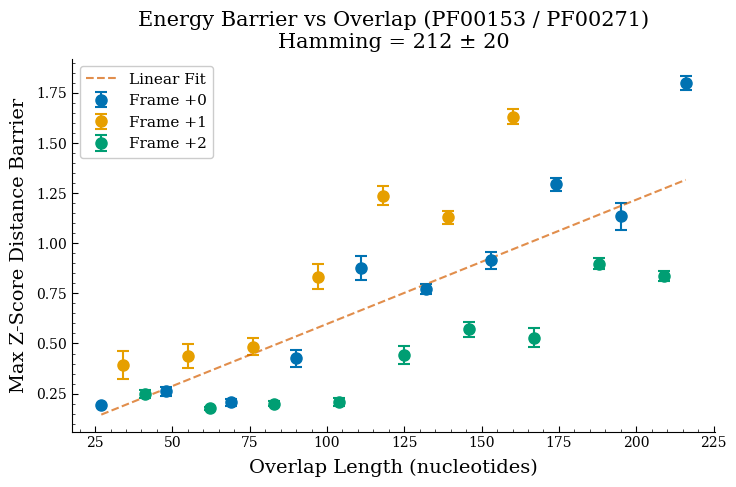


Linear Fit


In [15]:
# ===================== MAIN PLOT: Barrier vs Overlap =====================

if len(df_success) > 0:
    fig, ax = plt.subplots(figsize=(7.5, 5))

    # Group by overlap for error bars
    grouped = df_success.groupby('overlap')['max_barrier']
    ov_vals = grouped.mean().index.values
    means = grouped.mean().values
    stds = grouped.std().values
    counts = grouped.count().values
    sems = stds / np.sqrt(counts)

    # Color by reading frame
    frame_colors = FRAME_COLORS
    frame_labels_added = set()

    for ov, m, sem in zip(ov_vals, means, sems):
        rf = compute_reading_frame(ov)
        color = frame_colors.get(rf, 'gray')
        label = f'Frame +{rf}' if rf not in frame_labels_added else None
        ax.errorbar(ov, m, yerr=sem, fmt='o', color=color, markersize=8,
                    capsize=4, capthick=1.5, label=label)
        frame_labels_added.add(rf)

    # Linear regression
    from scipy import stats as sp_stats
    slope, intercept, r_value, p_value, std_err = sp_stats.linregress(ov_vals, means)
    x_fit = np.linspace(ov_vals.min(), ov_vals.max(), 100)
    ax.plot(x_fit, slope * x_fit + intercept, '--', color=VERMILLION, alpha=0.7,
            label=f'Linear Fit')

    ax.set_xlabel('Overlap Length (nucleotides)', fontsize=14)
    ax.set_ylabel('Max Z-Score Distance Barrier', fontsize=14)
    ax.set_title(f'Energy Barrier vs Overlap ({PROTEIN_1} / {PROTEIN_2})\n'
                 f'Hamming = {TARGET_HAMMING} \u00b1 {HAMMING_TOLERANCE}', fontsize=15)
    ax.legend(fontsize=11)
    plt.tight_layout()
    plt.savefig(f'hamming_controlled_barrier_vs_overlap_{PAIR_TAG}.png')
    plt.show()
    print(f"\nLinear Fit")
else:
    print("No data to plot.")

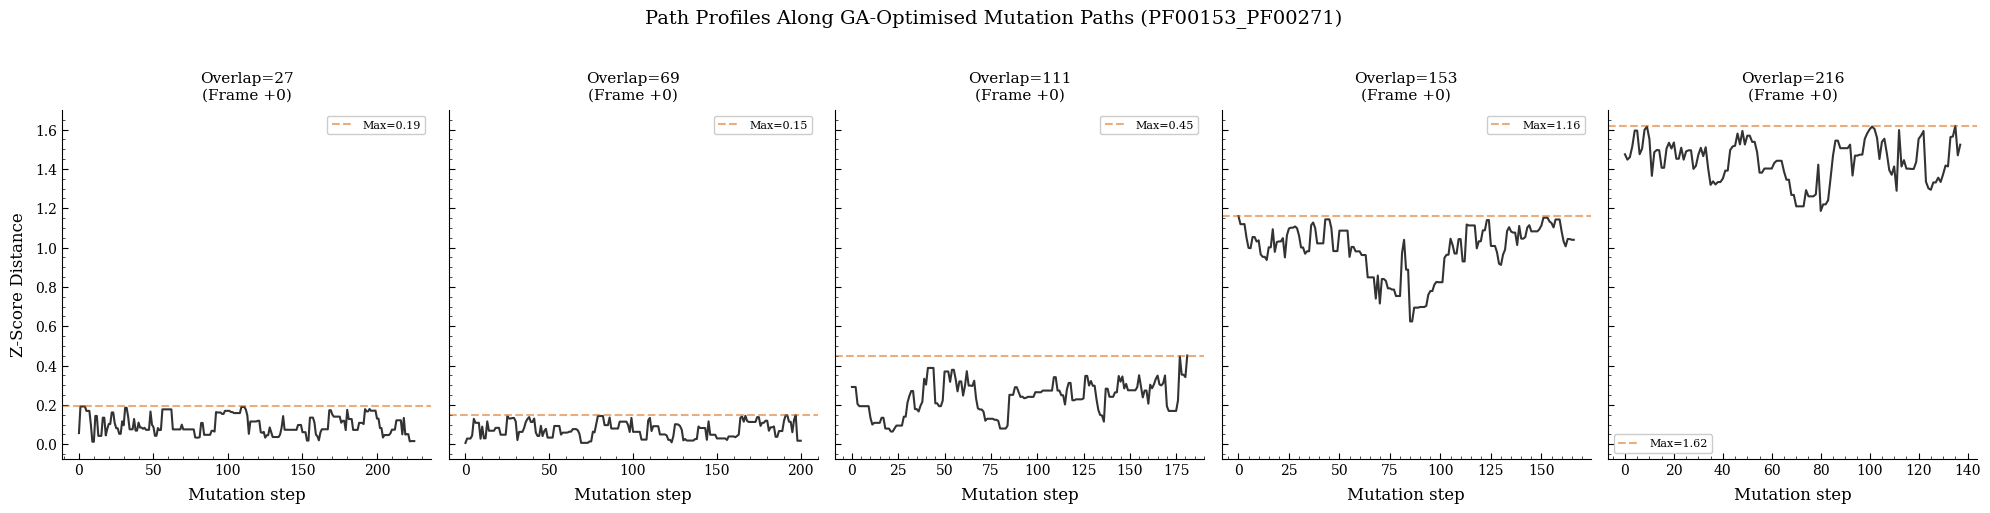

In [9]:
# ===================== PATH PROFILES =====================

if len(all_results) > 0:
    # Select ~5 representative overlap values
    successful_overlaps = sorted(df_success['overlap'].unique())
    if len(successful_overlaps) >= 5:
        indices = np.linspace(0, len(successful_overlaps) - 1, 5, dtype=int)
        representative_overlaps = [successful_overlaps[i] for i in indices]
    else:
        representative_overlaps = successful_overlaps

    fig, axes = plt.subplots(1, len(representative_overlaps),
                              figsize=(4 * len(representative_overlaps), 5),
                              sharey=True)
    if len(representative_overlaps) == 1:
        axes = [axes]

    for ax, ov in zip(axes, representative_overlaps):
        for r in all_results:
            if r['overlap'] == ov and r.get('success', True) and len(r.get('path_distances', [])) > 1:
                dists = np.array(r['path_distances'])
                steps = np.arange(len(dists))
                ax.plot(steps, dists, '-', alpha=0.8, linewidth=1.5)
                ax.axhline(y=r['max_barrier'], color=VERMILLION, linestyle='--',
                           alpha=0.5, label=f'Max={r["max_barrier"]:.2f}')
                break

        rf = compute_reading_frame(ov)
        ax.set_title(f'Overlap={ov}\n(Frame +{rf})', fontsize=11)
        ax.set_xlabel('Mutation step')
        ax.legend(fontsize=8)

    axes[0].set_ylabel('Z-Score Distance')
    fig.suptitle(f'Path Profiles Along GA-Optimised Mutation Paths ({PAIR_TAG})',
                 fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig(f'hamming_controlled_path_profiles_{PAIR_TAG}.png')
    plt.show()
else:
    print("No results for path profiles.")

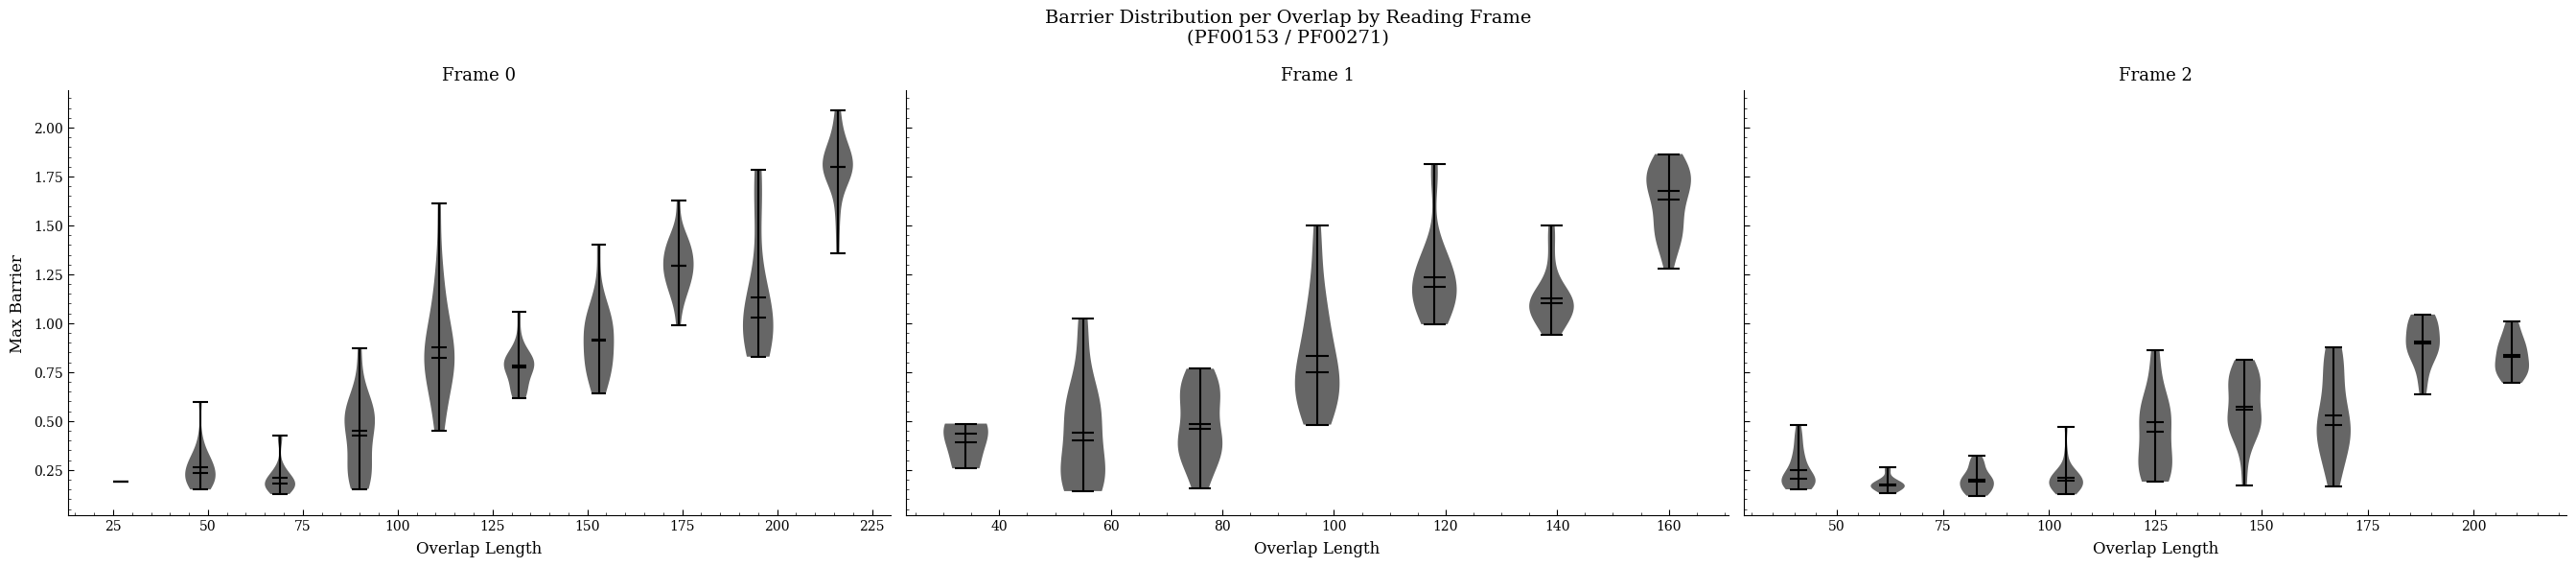

In [10]:
# ===================== PER-FRAME BREAKDOWN =====================

if len(df_success) > 0:
    unique_frames = sorted(df_success['reading_frame'].unique())
    n_frames = len(unique_frames)

    fig, axes = plt.subplots(1, max(n_frames, 1), figsize=(9 * max(n_frames, 1), 6),
                              sharey=True, squeeze=False)
    axes = axes[0]

    for idx, frame in enumerate(unique_frames):
        ax = axes[idx]
        frame_data = df_success[df_success['reading_frame'] == frame]

        overlaps_in_frame = sorted(frame_data['overlap'].unique())
        violin_data = [frame_data[frame_data['overlap'] == ov]['max_barrier'].values
                       for ov in overlaps_in_frame]

        # Filter out empty arrays
        valid = [(ov, d) for ov, d in zip(overlaps_in_frame, violin_data) if len(d) > 0]
        if valid:
            positions, data = zip(*valid)
            parts = ax.violinplot(data, positions=positions, widths=8,
                                  showmeans=True, showmedians=True)
            for pc in parts['bodies']:
                pc.set_alpha(0.6)

        ax.set_title(f'Frame {frame}', fontsize=13)
        ax.set_xlabel('Overlap Length', fontsize=12)
        if idx == 0:
            ax.set_ylabel('Max Barrier', fontsize=12)

    fig.suptitle(f'Barrier Distribution per Overlap by Reading Frame\n'
                 f'({PROTEIN_1} / {PROTEIN_2})', fontsize=14)
    plt.tight_layout()
    plt.savefig(f'hamming_controlled_per_frame_{PAIR_TAG}.png')
    plt.show()
else:
    print("No data for per-frame breakdown.")

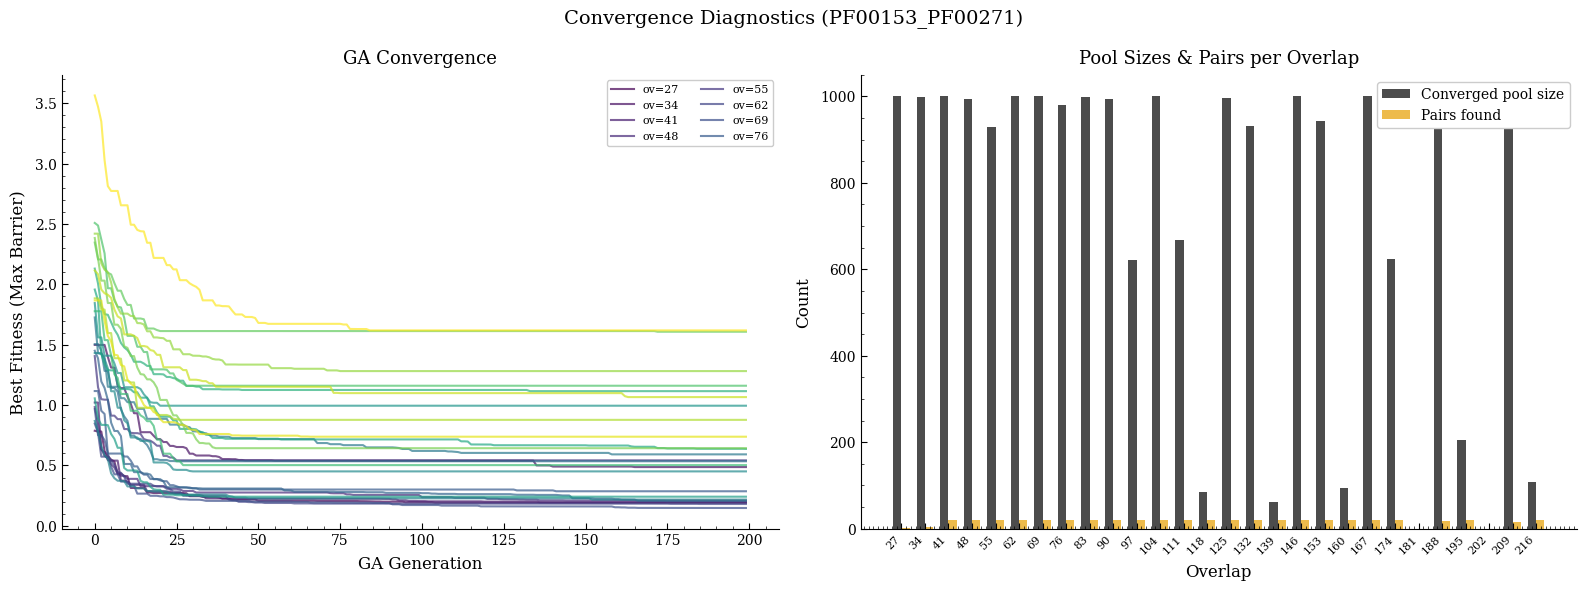

In [11]:
# ===================== CONVERGENCE DIAGNOSTICS =====================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- Left: GA fitness history curves ---
if len(all_results) > 0:
    successful_overlaps = sorted(df_success['overlap'].unique())
    cmap = plt.cm.viridis(np.linspace(0, 1, len(successful_overlaps)))

    for ov_idx, ov in enumerate(successful_overlaps):
        for r in all_results:
            if r['overlap'] == ov and r.get('success', True) and len(r.get('fitness_history', [])) > 0:
                ax1.plot(r['fitness_history'], color=cmap[ov_idx], alpha=0.7,
                         label=f'ov={ov}' if ov_idx < 8 else None)
                break

    ax1.set_xlabel('GA Generation', fontsize=12)
    ax1.set_ylabel('Best Fitness (Max Barrier)', fontsize=12)
    ax1.set_title('GA Convergence', fontsize=13)
    ax1.legend(fontsize=8, ncol=2, loc='upper right')

# --- Right: Pool sizes and pairs found ---
pool_sizes = []
pairs_found = []
ov_labels = []

# pool_cache may be full dicts (from computation) or empty (after reload)
# Fall back to saved pool_cache_sizes if available
saved_pool_sizes = {}
if isinstance(pool_cache, dict) and pool_cache:
    # Check if values are lists (full cache) or already sizes
    first_val = next(iter(pool_cache.values()), None)
    if isinstance(first_val, list):
        saved_pool_sizes = {ov: len(seqs) for ov, seqs in pool_cache.items()}
    elif isinstance(first_val, (int, float)):
        saved_pool_sizes = pool_cache
elif 'saved' in dir() and 'pool_cache_sizes' in saved:
    saved_pool_sizes = saved['pool_cache_sizes']

for ov in overlaps:
    pool_size = saved_pool_sizes.get(ov, 0)
    n_pairs = len([r for r in all_results
                   if r['overlap'] == ov and r.get('success', True)])
    pool_sizes.append(pool_size)
    pairs_found.append(n_pairs)
    ov_labels.append(str(ov))

x = np.arange(len(ov_labels))
width = 0.35
ax2.bar(x - width/2, pool_sizes, width, label='Converged pool size', alpha=0.7)
ax2.bar(x + width/2, pairs_found, width, label='Pairs found', alpha=0.7)
ax2.set_xticks(x)
ax2.set_xticklabels(ov_labels, rotation=45, ha='right', fontsize=8)
ax2.set_xlabel('Overlap', fontsize=12)
ax2.set_ylabel('Count', fontsize=12)
ax2.set_title('Pool Sizes & Pairs per Overlap', fontsize=13)
ax2.legend(fontsize=10)

fig.suptitle(f'Convergence Diagnostics ({PAIR_TAG})', fontsize=14)
plt.tight_layout()
plt.savefig(f'hamming_controlled_diagnostics_{PAIR_TAG}.png')
plt.show()

In [12]:
# ===================== STATISTICAL SUMMARY =====================

if len(df_success) > 0:
    from scipy import stats as sp_stats

    print("=" * 60)
    print("STATISTICAL SUMMARY")
    print("=" * 60)

    # Overall regression
    slope, intercept, r_value, p_value, std_err = sp_stats.linregress(
        df_success['overlap'], df_success['max_barrier'])
    print(f"\nOverall linear regression:")
    print(f"  slope     = {slope:.6f} +/- {std_err:.6f}")
    print(f"  intercept = {intercept:.4f}")
    print(f"  R\u00b2        = {r_value**2:.4f}")
    print(f"  p-value   = {p_value:.2e}")
    print(f"  N         = {len(df_success)}")

    # Per-frame regression
    print(f"\nPer-frame regressions:")
    for frame in sorted(df_success['reading_frame'].unique()):
        fdata = df_success[df_success['reading_frame'] == frame]
        if len(fdata) >= 3 and fdata['overlap'].nunique() >= 2:
            s, i, r, p, se = sp_stats.linregress(fdata['overlap'], fdata['max_barrier'])
            print(f"  Frame {frame}: slope={s:.6f}+/-{se:.6f}, "
                  f"R\u00b2={r**2:.4f}, p={p:.2e}, N={len(fdata)}")
        else:
            print(f"  Frame {frame}: insufficient data (N={len(fdata)})")

    # Summary table
    print(f"\nSummary table:")
    summary = df_success.groupby('overlap').agg(
        barrier_mean=('max_barrier', 'mean'),
        barrier_std=('max_barrier', 'std'),
        barrier_min=('max_barrier', 'min'),
        barrier_max=('max_barrier', 'max'),
        hamming_mean=('hamming_dist', 'mean'),
        n_trials=('max_barrier', 'count'),
        reading_frame=('reading_frame', 'first')
    ).round(4)
    display(summary)

    # Hamming distance verification
    print(f"\nHamming distance verification:")
    print(f"  Target: {TARGET_HAMMING} +/- {HAMMING_TOLERANCE}")
    print(f"  Actual range: [{df_success['hamming_dist'].min()}, {df_success['hamming_dist'].max()}]")
    print(f"  Actual mean: {df_success['hamming_dist'].mean():.1f}")
else:
    print("No successful results for statistical summary.")

STATISTICAL SUMMARY

Overall linear regression:
  slope     = 0.006698 +/- 0.000313
  intercept = -0.0843
  R²        = 0.4925
  p-value   = 2.18e-71
  N         = 473

Per-frame regressions:
  Frame 0: slope=0.008450+/-0.000328, R²=0.7883, p=6.60e-62, N=180
  Frame 1: slope=0.010969+/-0.000591, R²=0.7401, p=3.30e-37, N=123
  Frame 2: slope=0.004309+/-0.000239, R²=0.6590, p=4.28e-41, N=170

Summary table:


,barrier_mean,barrier_std,barrier_min,barrier_max,hamming_mean,n_trials,reading_frame
overlap,,,,,,,
27,0.1918,NaN,0.1918,0.1918,230.0000,1,0
34,0.3926,0.1196,0.2579,0.4865,230.3333,3,1
41,0.2493,0.0939,0.1504,0.4776,225.7500,20,2
48,0.2613,0.1052,0.1495,0.5990,227.8000,20,0
55,0.4380,0.2623,0.1412,1.0231,224.8500,20,1
62,0.1759,0.0340,0.1299,0.2611,216.0500,20,2
69,0.2072,0.0791,0.1263,0.4231,214.0000,20,0
76,0.4843,0.1866,0.1544,0.7672,215.7500,20,1
83,0.1993,0.0601,0.1177,0.3206,212.0000,20,2



Hamming distance verification:
  Target: 212 +/- 20
  Actual range: [208, 232]
  Actual mean: 214.8


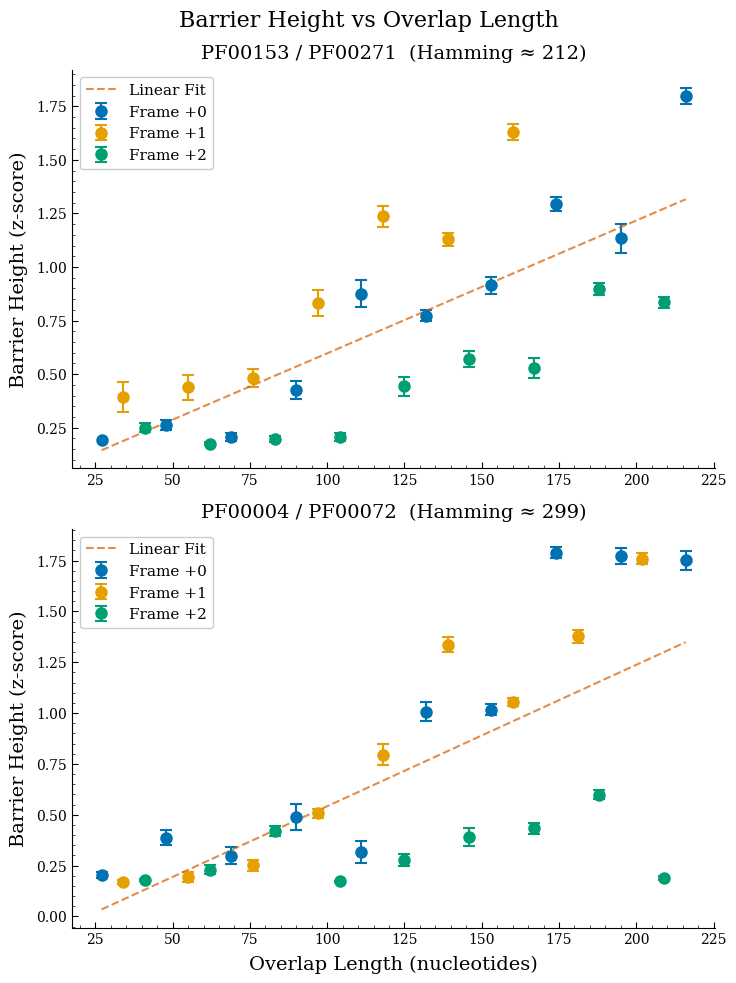

In [16]:
# ===================== COMBINED PLOT: Two Pairs Stacked =====================

from scipy import stats as sp_stats

def compute_reading_frame(overlap):
    return overlap % 3

frame_colors = FRAME_COLORS

# Load both CSVs
df_153_271 = pd.read_csv('hamming_controlled_results_PF00153_PF00271.csv')
df_153_271 = df_153_271[df_153_271['success']].copy()

df_4_72 = pd.read_csv('hamming_controlled_results_PF00004_PF00072.csv')
df_4_72 = df_4_72[df_4_72['success']].copy()

h_153 = int(df_153_271['hamming_dist'].median())
h_4   = int(df_4_72['hamming_dist'].median())

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7.5, 10))

for ax, df_pair, pair_label, h_target in [
    (ax1, df_153_271, 'PF00153 / PF00271', h_153),
    (ax2, df_4_72,    'PF00004 / PF00072', h_4),
]:
    grouped = df_pair.groupby('overlap')['max_barrier']
    ov_vals = grouped.mean().index.values
    means = grouped.mean().values
    stds = grouped.std().values
    counts = grouped.count().values
    sems = stds / np.sqrt(counts)

    frame_labels_added = set()
    for ov, m, sem in zip(ov_vals, means, sems):
        rf = compute_reading_frame(ov)
        color = frame_colors.get(rf, 'gray')
        label = f'Frame +{rf}' if rf not in frame_labels_added else None
        ax.errorbar(ov, m, yerr=sem, fmt='o', color=color, markersize=8,
                    capsize=4, capthick=1.5, label=label)
        frame_labels_added.add(rf)

    slope, intercept, r_value, p_value, std_err = sp_stats.linregress(ov_vals, means)
    x_fit = np.linspace(ov_vals.min(), ov_vals.max(), 100)
    ax.plot(x_fit, slope * x_fit + intercept, '--', color=VERMILLION, alpha=0.7,
            label=f'Linear Fit')

    ax.set_ylabel('Barrier Height (z-score)', fontsize=14)
    ax.set_title(f'{pair_label}  (Hamming \u2248 {h_target})', fontsize=14)
    ax.legend(fontsize=11)

ax2.set_xlabel('Overlap Length (nucleotides)', fontsize=14)
fig.suptitle('Barrier Height vs Overlap Length', fontsize=16)
plt.tight_layout()
plt.savefig('hamming_controlled_barrier_vs_overlap_combined.png')
plt.show()